# Bar Plot Gallery

Bar plots compare values across discrete categories. They're the workhorse chart for retail analytics: sales by store, revenue by channel, market share by brand. The eye reads height (or length) directly, so they work well for ranking, comparison, and part-to-whole questions when the categories are few.

Bar plots excel at:
- **Category comparison**: rank products, regions, or stores against each other
- **Grouped comparison**: line up multiple metrics (target vs actual, this year vs last) per category
- **Part-to-whole**: combined with percentage labels, show what each bar contributes to the total
- **Long category names**: switch to horizontal bars when category labels won't fit on the x-axis

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from openretailscience.plots import bar
from openretailscience.plots.styles.graph_utils import set_axis_shorthand

In [ ]:
# Hand-crafted demo datasets shared across the gallery examples.
# Each dataset is sized so the chart's headline is true at a glance.

product_sales = pd.DataFrame(
    {"sales": [240_000, 180_000, 320_000, 90_000, 145_000, 110_000]},
    index=["Electronics", "Apparel", "Home & Garden", "Sports", "Books", "Toys"],
)

store_performance = pd.DataFrame(
    {
        "store": ["Camden High St", "Brixton Hill", "Shoreditch", "Clapham Junction", "Islington"],
        "revenue": [245_000, 189_000, 310_000, 198_000, 221_000],
    },
)

quarterly_channel_sales = pd.DataFrame(
    {
        "quarter": ["Q1", "Q2", "Q3", "Q4"],
        "Online": [180_000, 210_000, 245_000, 290_000],
        "Stores": [320_000, 315_000, 305_000, 310_000],
        "Wholesale": [95_000, 105_000, 115_000, 108_000],
    },
)

category_revenue = pd.DataFrame(
    {
        "category": [
            "Consumer Electronics",
            "Home & Kitchen Appliances",
            "Sporting Goods & Outdoors",
            "Health & Personal Care",
            "Books & Media",
        ],
        "revenue": [425_000, 312_000, 198_000, 267_000, 145_000],
    },
)

sales_rep_data = pd.DataFrame(
    {
        "sales_rep": [
            "Aisha Khan",
            "Liam O'Connor",
            "Priya Patel",
            "Emma Walsh",
            "Tom Bennett",
            "Sofia Russo",
        ],
        "sales_amount": [89_000, 134_000, 67_000, 156_000, 98_000, 112_000],
    },
)

regional_sales = pd.DataFrame(
    {
        "region": ["North", "South", "East", "West"],
        "sales": [285_000, 231_000, 198_000, 267_000],
    },
)

market_share_data = pd.DataFrame(
    {
        "brand": ["Cadbury", "Mars", "Nestle", "Lindt", "Ferrero"],
        "market_share": [35, 28, 18, 12, 7],
    },
)

monthly_performance = pd.DataFrame(
    {
        "month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
        "Target Sales": [150_000, 145_000, 160_000, 155_000, 165_000, 170_000],
        "Actual Sales": [142_000, 138_000, 168_000, 149_000, 172_000, 163_000],
    },
)

customer_satisfaction = pd.Series(
    [4.2, 4.5, 3.8, 4.1, 4.7, 3.9, 4.3],
    index=["Service", "Quality", "Price", "Delivery", "Support", "Returns", "Overall"],
    name="Satisfaction Score",
)

department_data = pd.DataFrame(
    {
        "department": ["Sales", "Marketing", "Operations", "Customer Service"],
        "Q1": [92, 88, 95, 87],
        "Q2": [89, 91, 96, 90],
        "Q3": [91, 85, 94, 93],
    },
)

## Basic Bar Plot

The simplest call: pass a single `value_col` and the DataFrame's index becomes the category axis. Use this shape when the index already carries the categorical meaning (product names, region codes), so there's no need for a separate `x_col`.

---

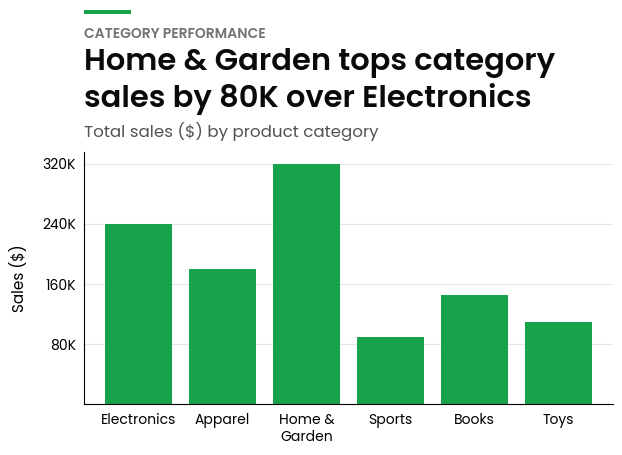

In [ ]:
ax = bar.plot(
    product_sales,
    value_col="sales",
    eyebrow="Category performance",
    title="Home & Garden tops category sales by 80K over Electronics",
    subtitle="Total sales ($) by product category",
    y_label="Sales ($)",
)
set_axis_shorthand(ax.yaxis)
plt.show()

## Using `x_col`

When the category labels live in a column rather than the index, point `x_col` at that column. Common when the data comes back from a SQL query that puts the category in its own column. The DataFrame's row order is preserved, so the bars appear in the order they sit in the data.

---

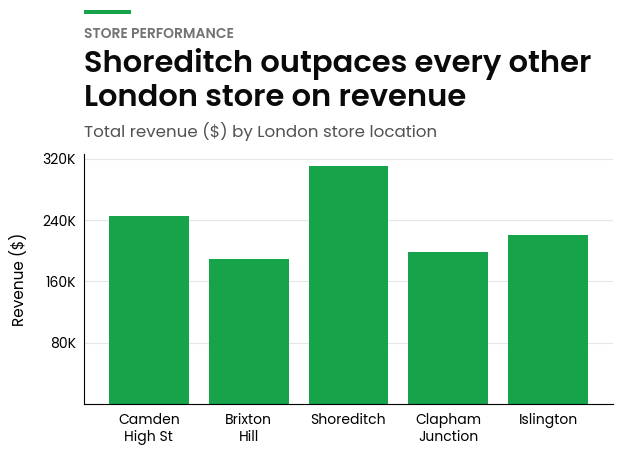

In [ ]:
ax = bar.plot(
    store_performance,
    x_col="store",
    value_col="revenue",
    eyebrow="Store performance",
    title="Shoreditch outpaces every other London store on revenue",
    subtitle="Total revenue ($) by London store location",
    y_label="Revenue ($)",
)
set_axis_shorthand(ax.yaxis)
plt.show()

## Multiple Value Columns (Grouped Bars)

Pass a list to `value_col` and each category gets a clustered set of bars, one per series. Use this shape when the upstream data is already in *wide format* (one column per series), as is common with SQL pivot output. Three or four series stays readable; more than that and the bars get too thin to compare.

---

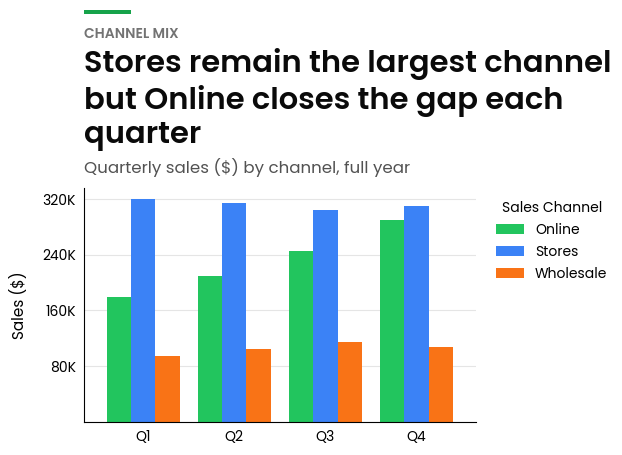

In [ ]:
ax = bar.plot(
    quarterly_channel_sales,
    x_col="quarter",
    value_col=["Online", "Stores", "Wholesale"],
    eyebrow="Channel mix",
    title="Stores remain the largest channel but Online closes the gap each quarter",
    subtitle="Quarterly sales ($) by channel, full year",
    y_label="Sales ($)",
    legend_title="Sales Channel",
    move_legend_outside=True,
)
set_axis_shorthand(ax.yaxis)
plt.show()

## Horizontal Bar Plot

Set `orientation="horizontal"` to lay the bars on their side. Pick this whenever category labels are long enough to crowd or rotate awkwardly on the x-axis. Bars run left-to-right, so the value axis is now the x-axis (use `set_axis_shorthand(ax.xaxis)` to format it).

---

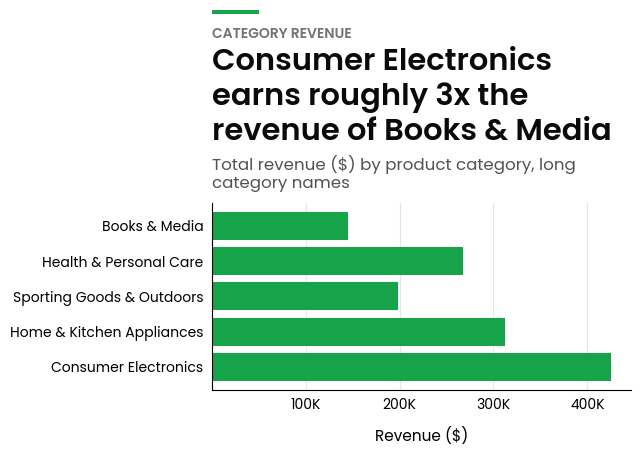

In [ ]:
ax = bar.plot(
    category_revenue,
    x_col="category",
    value_col="revenue",
    eyebrow="Category revenue",
    title="Consumer Electronics earns roughly 3x the revenue of Books & Media",
    subtitle="Total revenue ($) by product category, long category names",
    x_label="Revenue ($)",
    orientation="horizontal",
)
set_axis_shorthand(ax.xaxis)
plt.show()

## Sorted Bar Plot

Pass `sort_order="descending"` to rank vertical bars from tallest to shortest, so the eye lands on the leader first. Use `"ascending"` instead when the chart's job is triage rather than celebration. (For horizontal bars the convention flips: `"ascending"` puts the largest bar at the top of the chart.)

---

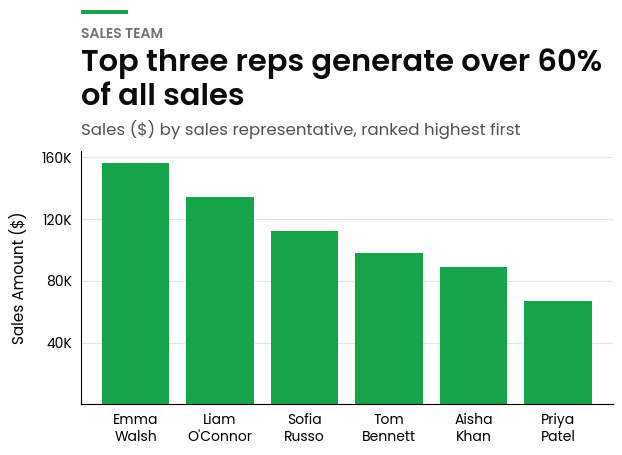

In [ ]:
ax = bar.plot(
    sales_rep_data,
    x_col="sales_rep",
    value_col="sales_amount",
    eyebrow="Sales team",
    title="Top three reps generate over 60% of all sales",
    subtitle="Sales ($) by sales representative, ranked highest first",
    y_label="Sales Amount ($)",
    sort_order="descending",
)
set_axis_shorthand(ax.yaxis)
plt.show()

## Bar Plot with Absolute Data Labels

Pass `data_label_format="absolute"` to write each bar's raw value above its top edge. Useful for small charts (under ten bars) where exact numbers matter and the reader shouldn't have to estimate from the y-axis. Values are formatted in shorthand (e.g. 285K, 1.2M) and truncated to `num_digits=3` significant digits by default.

---

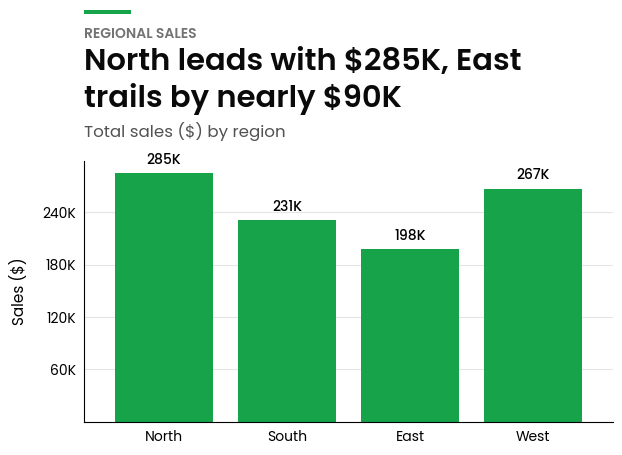

In [ ]:
ax = bar.plot(
    regional_sales,
    x_col="region",
    value_col="sales",
    eyebrow="Regional sales",
    title=r"North leads with \$285K, East trails by nearly \$90K",
    subtitle="Total sales ($) by region",
    y_label="Sales ($)",
    data_label_format="absolute",
)
set_axis_shorthand(ax.yaxis)
plt.show()

## Percentage Data Labels by Series

Pass `data_label_format="percentage_by_series"` to label each bar as its share of the column's total. Pick this for part-to-whole questions like market share or category mix where the total adds up to a meaningful 100%. The companion `"percentage_by_bar_group"` mode does the same per category group when you're plotting grouped bars.

---

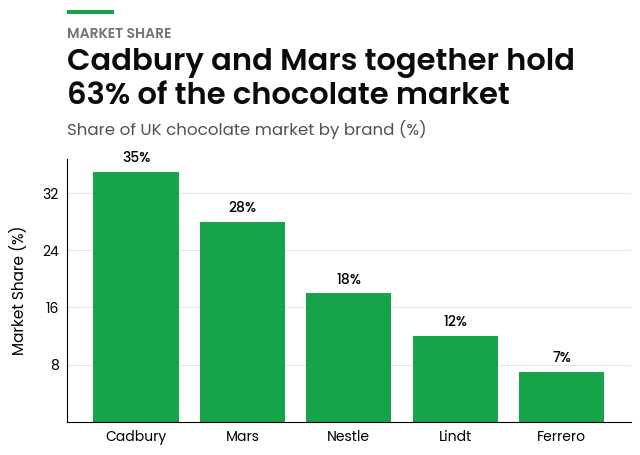

In [ ]:
ax = bar.plot(
    market_share_data,
    x_col="brand",
    value_col="market_share",
    eyebrow="Market share",
    title="Cadbury and Mars together hold 63% of the chocolate market",
    subtitle="Share of UK chocolate market by brand (%)",
    y_label="Market Share (%)",
    data_label_format="percentage_by_series",
)
plt.show()

## Bar Plot with Hatch Patterns

Set `use_hatch=True` to overlay a hatch pattern on each series. Useful when the chart will be printed in black and white, projected on a low-contrast screen, or needs to remain readable with colour-blind-friendly palettes. Each series gets a different hatch style, so they stay distinguishable even if the colours blur together.

---

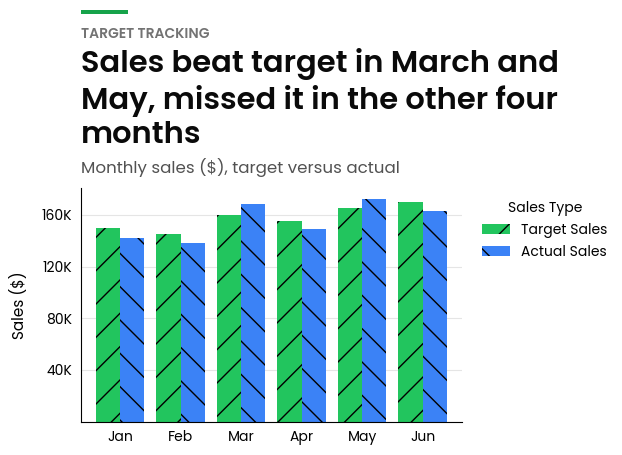

In [ ]:
ax = bar.plot(
    monthly_performance,
    x_col="month",
    value_col=["Target Sales", "Actual Sales"],
    eyebrow="Target tracking",
    title="Sales beat target in March and May, missed it in the other four months",
    subtitle="Monthly sales ($), target versus actual",
    y_label="Sales ($)",
    legend_title="Sales Type",
    use_hatch=True,
    move_legend_outside=True,
)
set_axis_shorthand(ax.yaxis)
plt.show()

## Plotting a Pandas Series

A `Series` works directly: the function uses the index for category labels and the series name for the legend. Useful when the upstream computation (e.g. a `groupby().mean()`) already returns a Series and you don't want to wrap it just to plot.

---

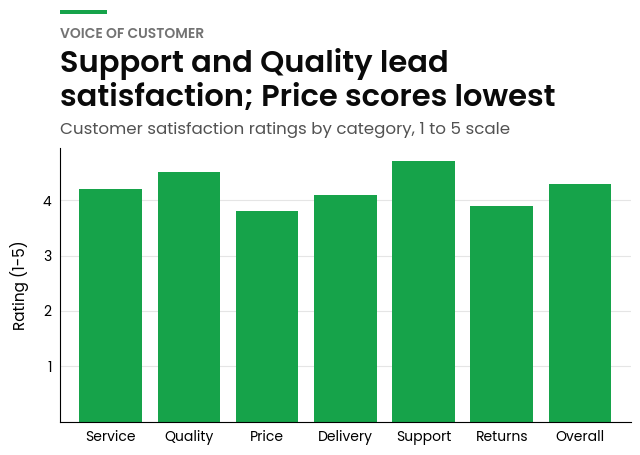

In [ ]:
ax = bar.plot(
    customer_satisfaction,
    value_col="Satisfaction Score",
    eyebrow="Voice of customer",
    title="Support and Quality lead satisfaction; Price scores lowest",
    subtitle="Customer satisfaction ratings by category, 1 to 5 scale",
    y_label="Rating (1-5)",
)
plt.show()

## Advanced Styling Options

Two knobs worth knowing: `source_text` adds a small attribution line at the bottom of the chart for export-ready images, and `move_legend_outside=True` lifts the legend to the right edge so it never sits on top of the data. Both are no-cost additions on any chart that's headed for a slide or a public dashboard.

---

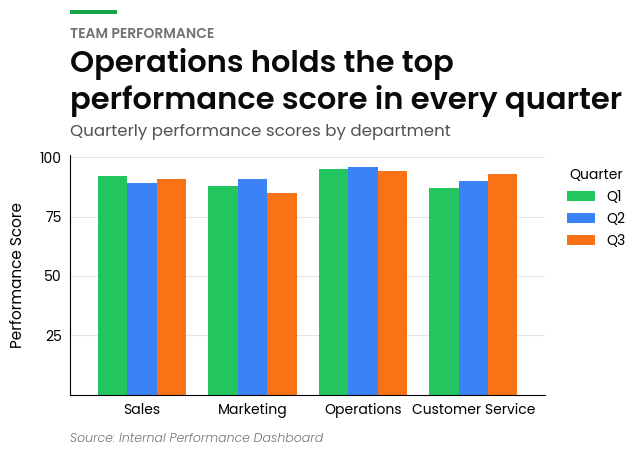

In [ ]:
ax = bar.plot(
    department_data,
    x_col="department",
    value_col=["Q1", "Q2", "Q3"],
    eyebrow="Team performance",
    title="Operations holds the top performance score in every quarter",
    subtitle="Quarterly performance scores by department",
    y_label="Performance Score",
    legend_title="Quarter",
    move_legend_outside=True,
    source_text="Source: Internal Performance Dashboard",
)
plt.show()